<a href="https://colab.research.google.com/github/HolaBaGa/tibame/blob/main/02MySQL_DQL_%E7%AD%86%E8%A8%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

來自講義 02MySQL-DQL 筆記
直播課時間5/23 下午

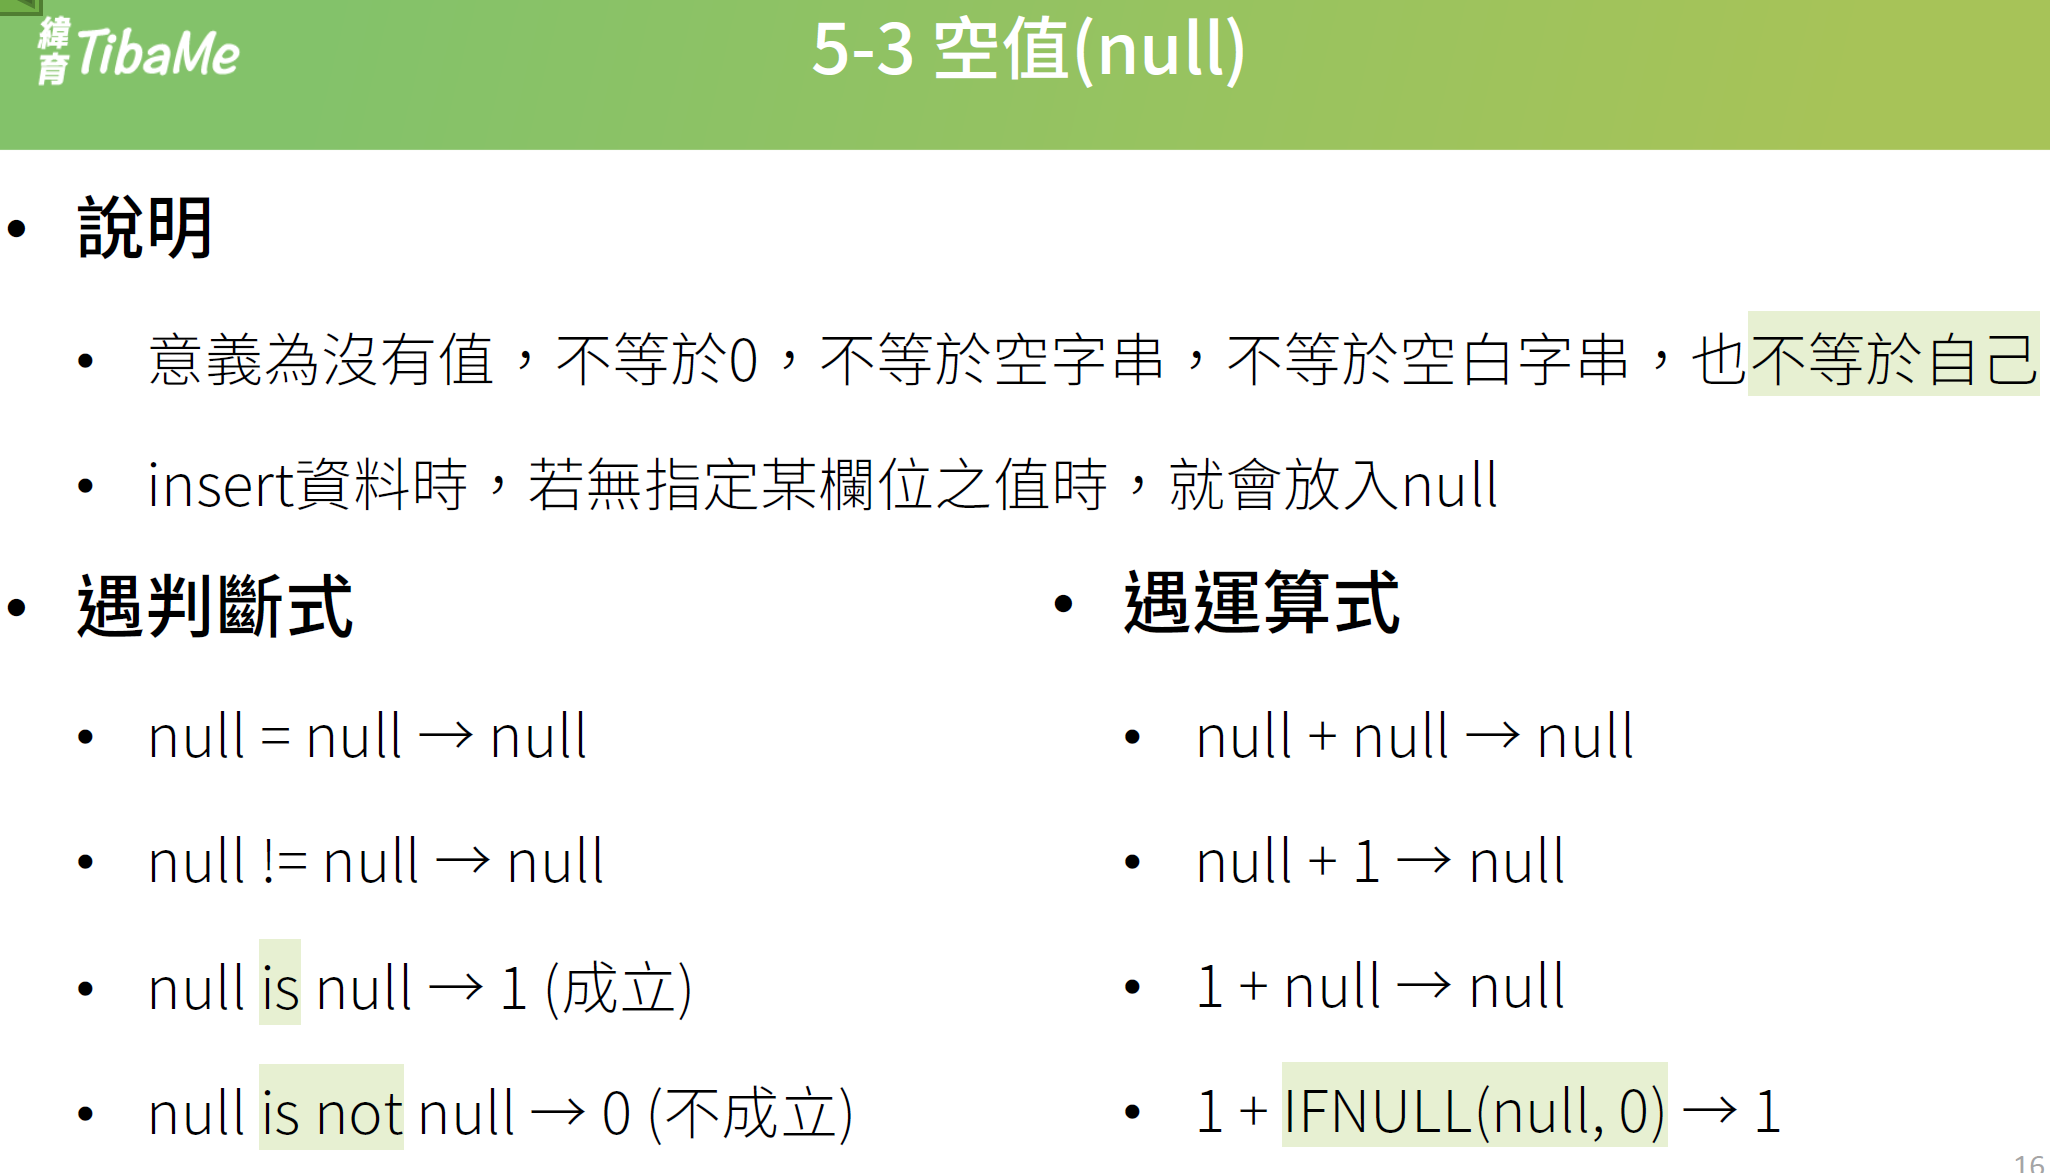

In [ ]:
# null 空質


select
	sal,
    comm,
    sal + ifnull(comm, 0)
    # 如果comm是空值, 為0帶出
from emp

match python 是什麼?

python/ sql 對照表


match/ case


case/ when

In [ ]:
# 函式頭尾都要先寫好, 特別是end 很容易忘記

select
	case deptno
		when 10 then "十"
        when 20 then "廿"
        else '未知'
    end as 部門編號
from emp

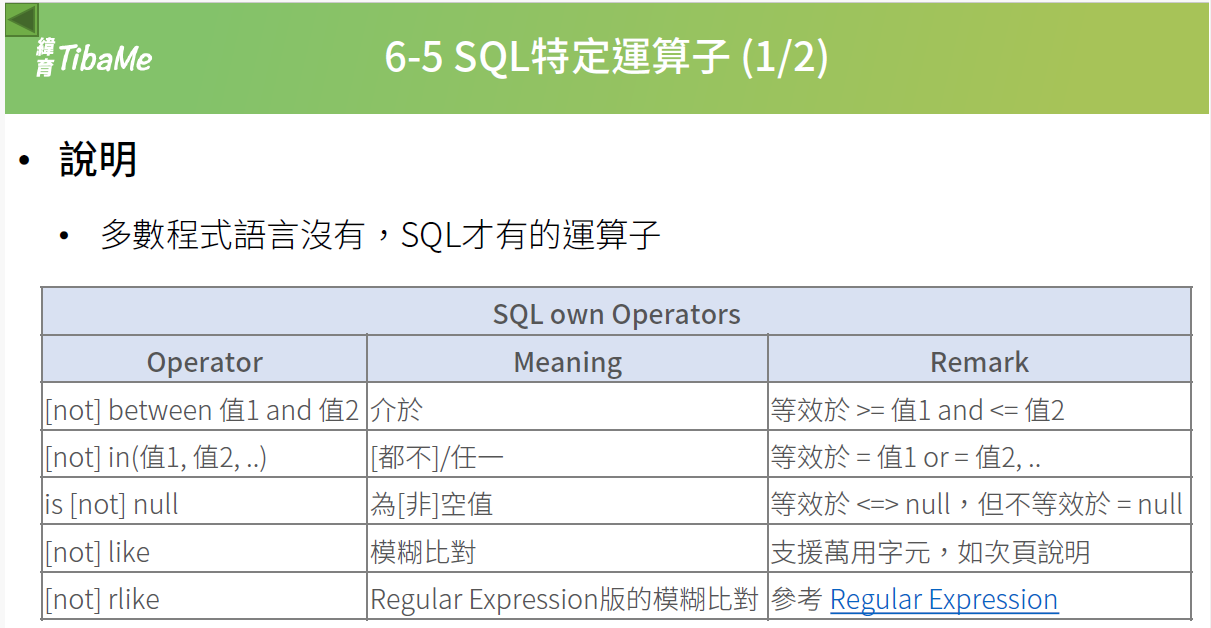



a + b 是 運算式


"+" 是 運算子


a 跟 b 是 運算元

SQL 只有 =

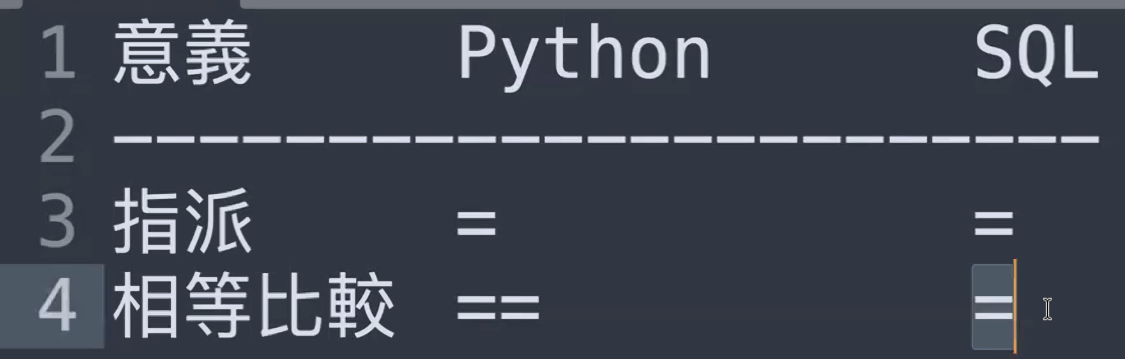

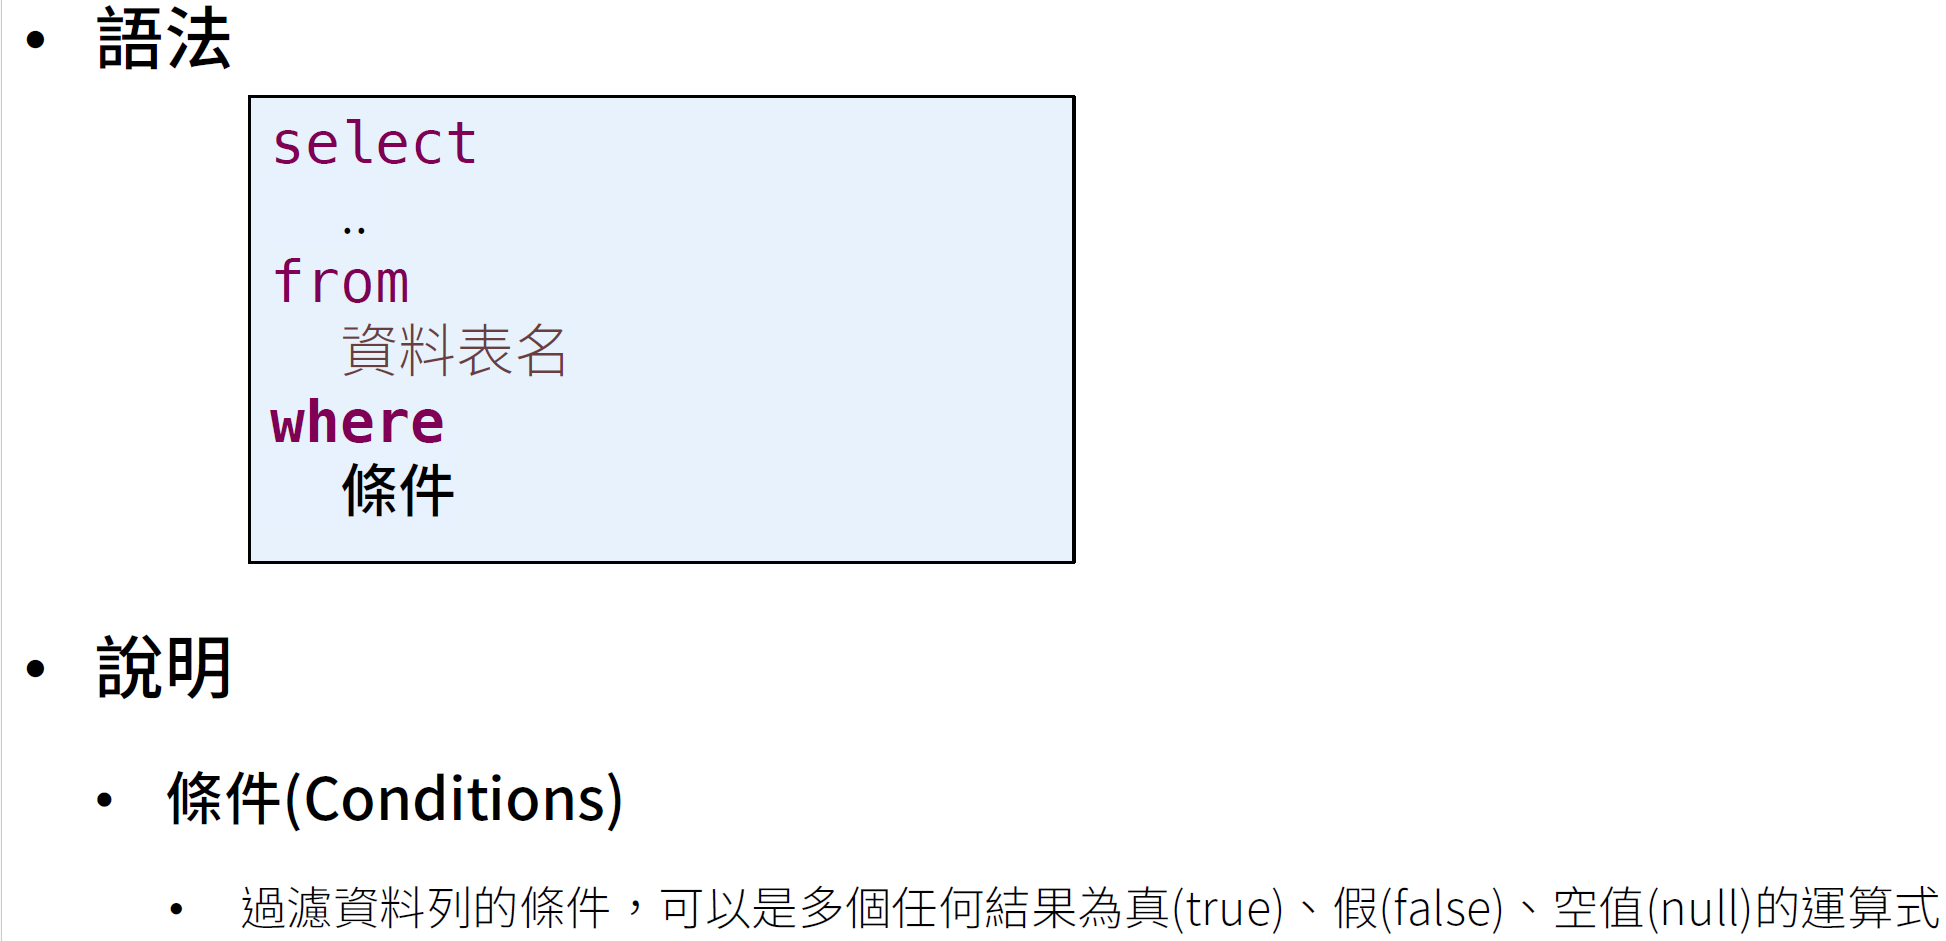

In [ ]:
select
	*
from
	EMP
where
	# 薪水 1000~2000
    # sal >= 1000 and sal <= 2000 # 傳統語法, 主詞要重複寫
	sal between 1000 and 2000

In [ ]:
select
	*
from
	EMP
where
	# 10, 20部門的員工
    # deptno = 10 or deptno = 20 # 傳統語法
	deptno in(10, 20)


 select
	*
from
	EMP
where
	# 不是10, 20部門的員工
    # deptno != 10 and deptno != 20
	deptno not in(10, 20)

In [ ]:
select
	*
from
	EMP
where
	comm is not null

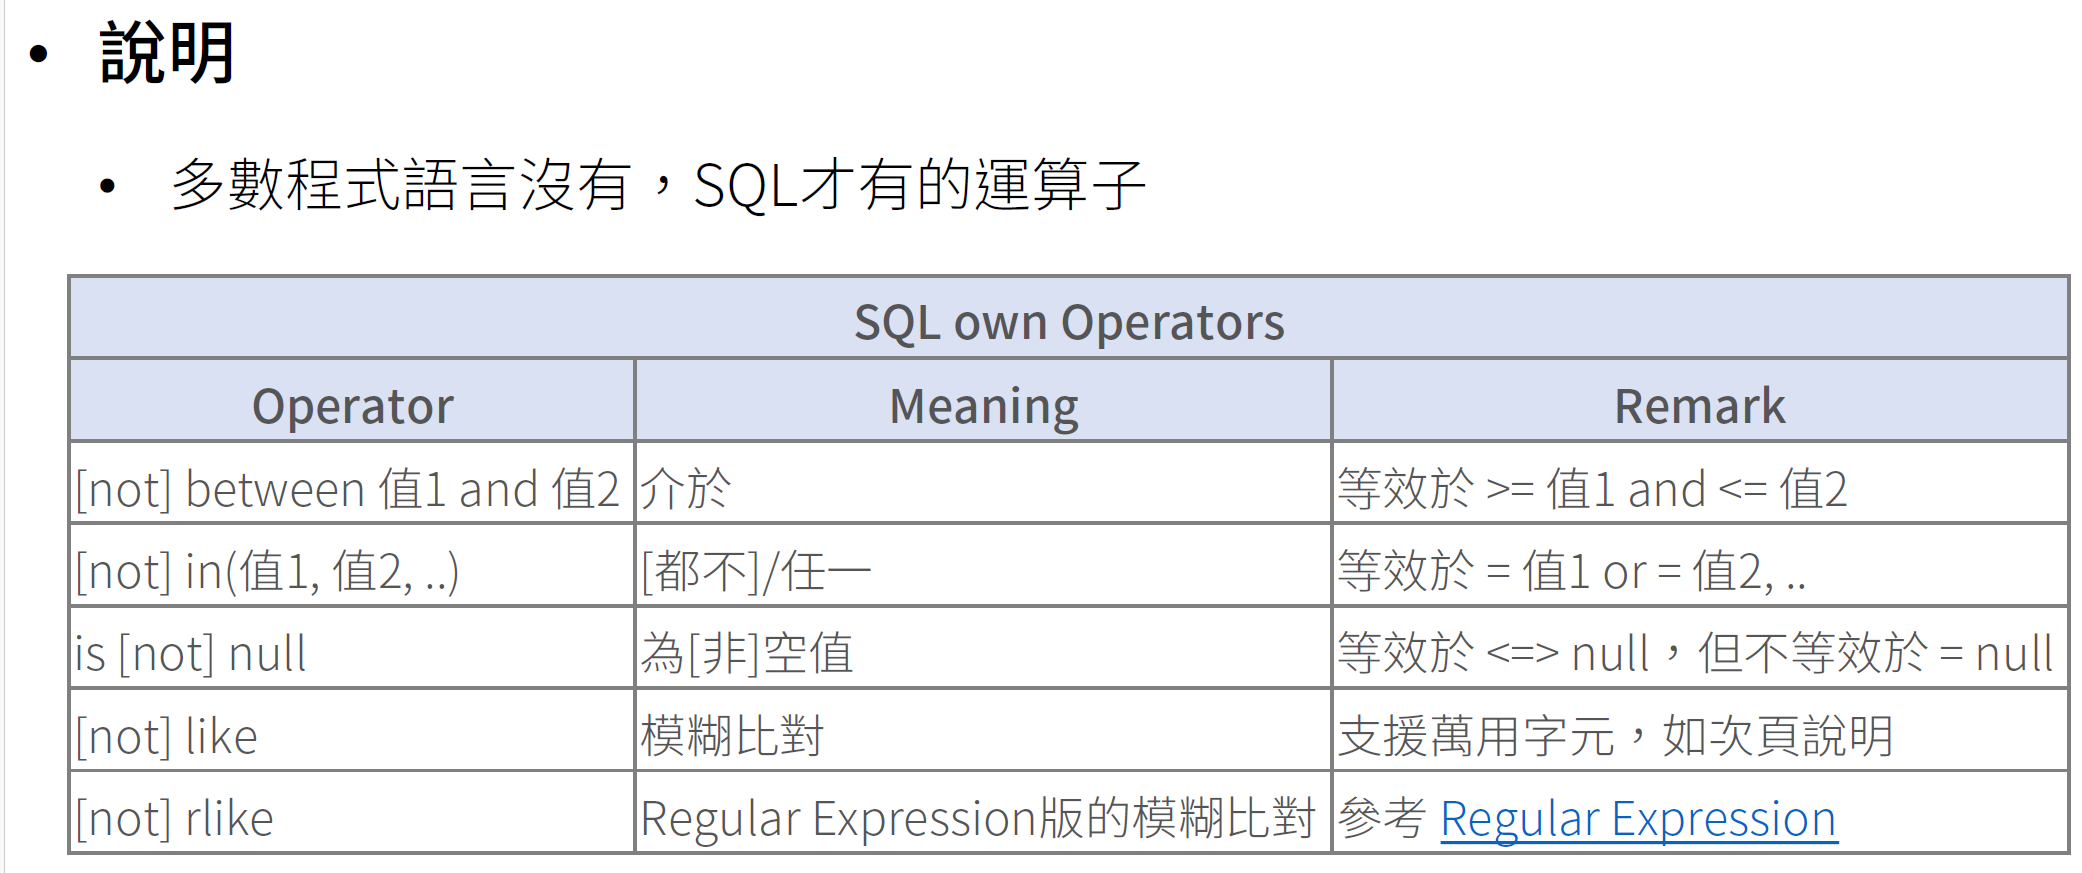

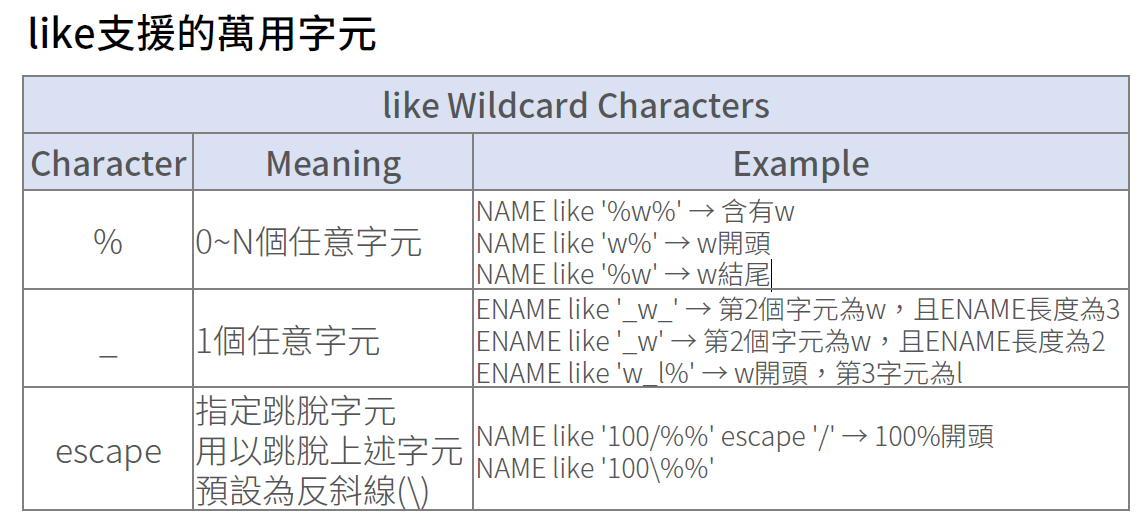

wildcard 表示萬用字

rlike 很少用, 可以用like表示就好

In [ ]:
# 找出 ALLEN 這個人


# 第一個字是A
select
	*
from
	EMP
where
	ename like 'A%'


# 第二個字是L
select
	*
from
	EMP
where
	ename like '_L%'


# 第三個字是L
select
	*
from
	EMP
where
	ename like '__L%'

# 讓\ 的右邊失去功能, 如範例, 我要找出前後任意數, 中有有%的名稱
select
	*
from
	EMP
where
	ename like '%\%%' escape '\'
# escape 後面的'\' 可自定義, 但大多數都用\

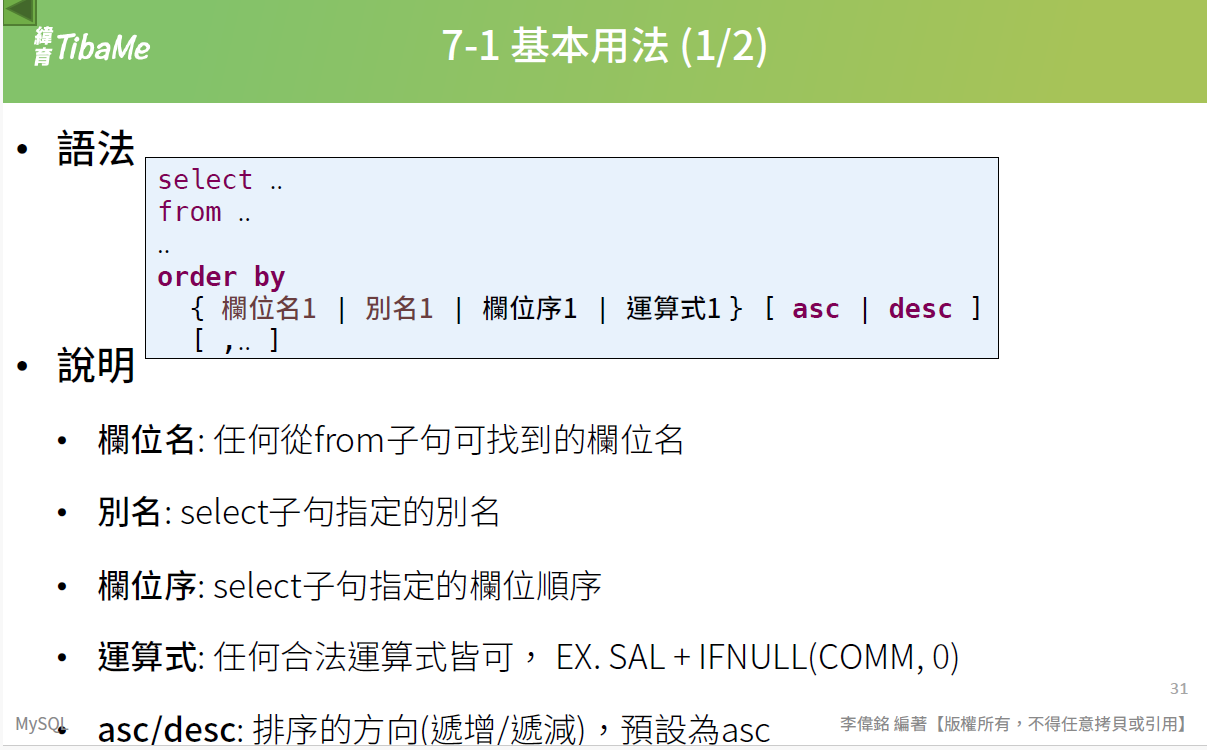

() sql 都用
{} 表示 內容
[] 表示 可有可無

asc 是遞增 (預設)
desc 遞減

大部分都用欄位名, 欄位序只有自己測試會用, 因不直觀

In [ ]:
# 先從deptno 排序, 相同再來按sal排序

select
	*
from
	EMP
order by
	deptno,
    sal desc

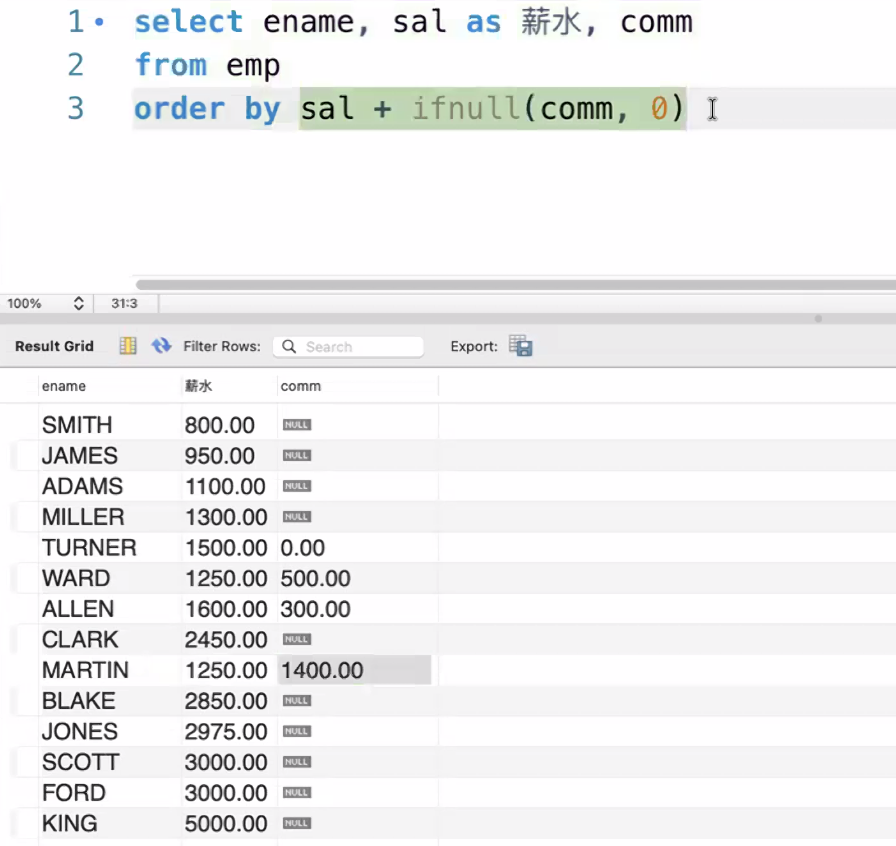

分組 並計算分別有幾個

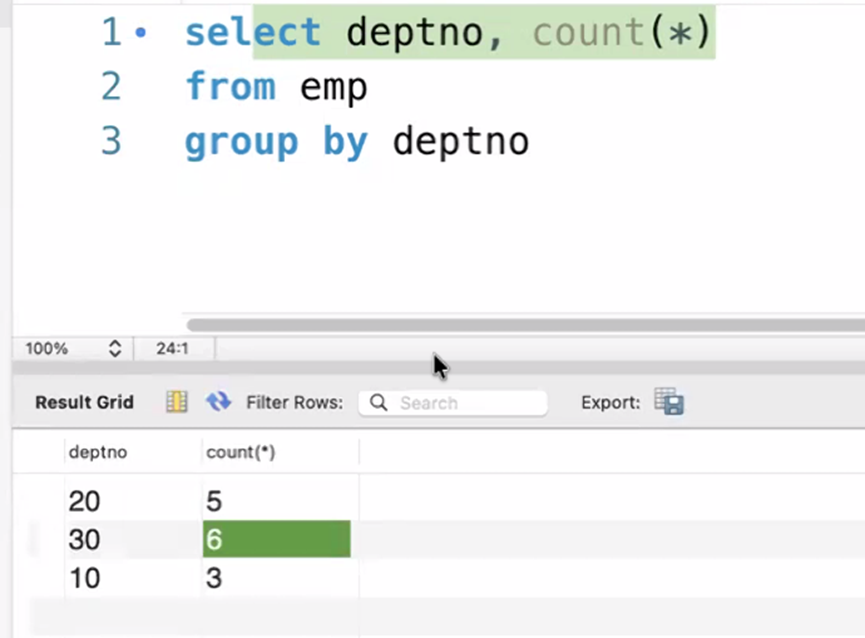

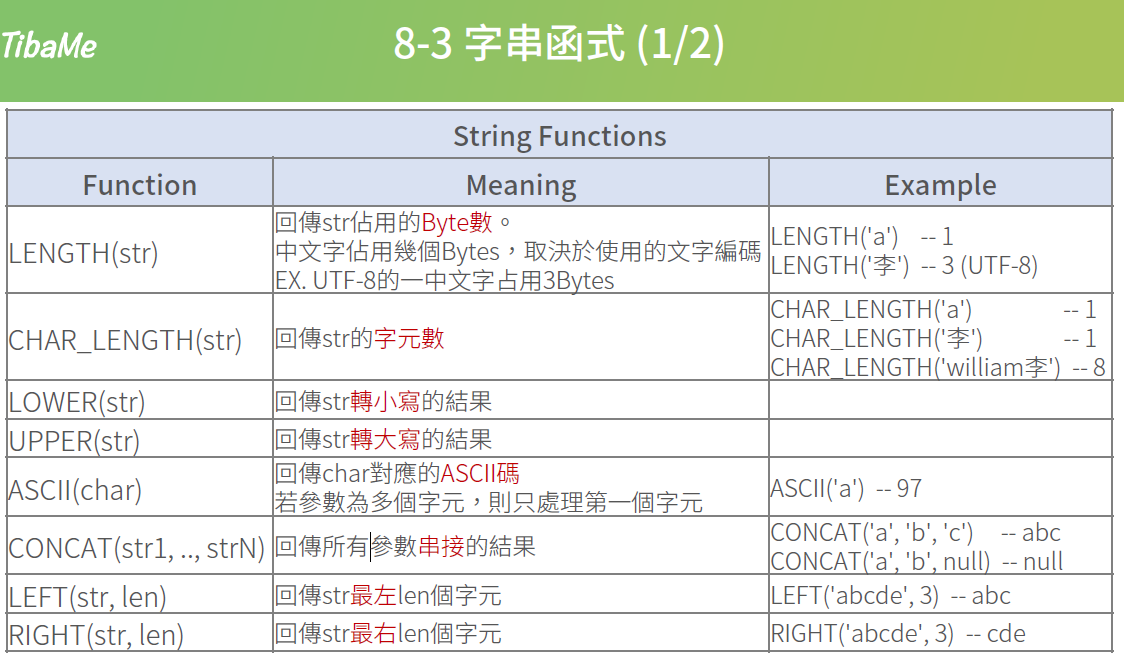

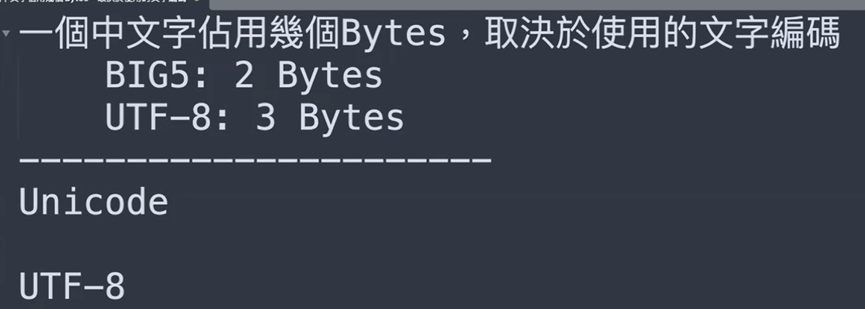

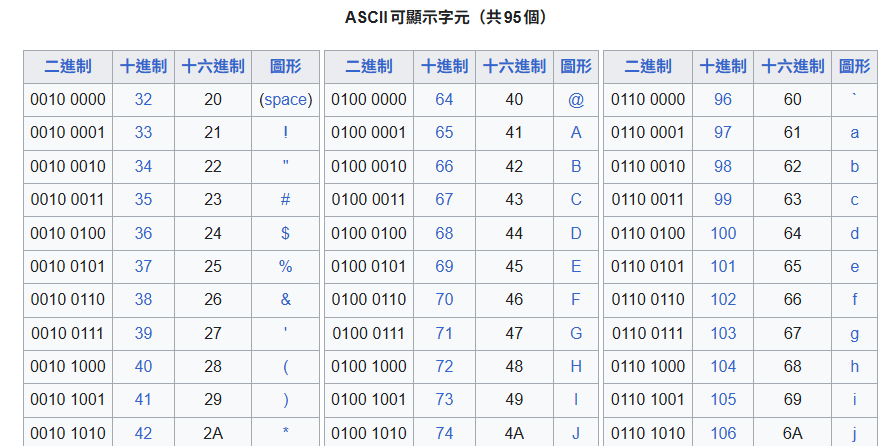

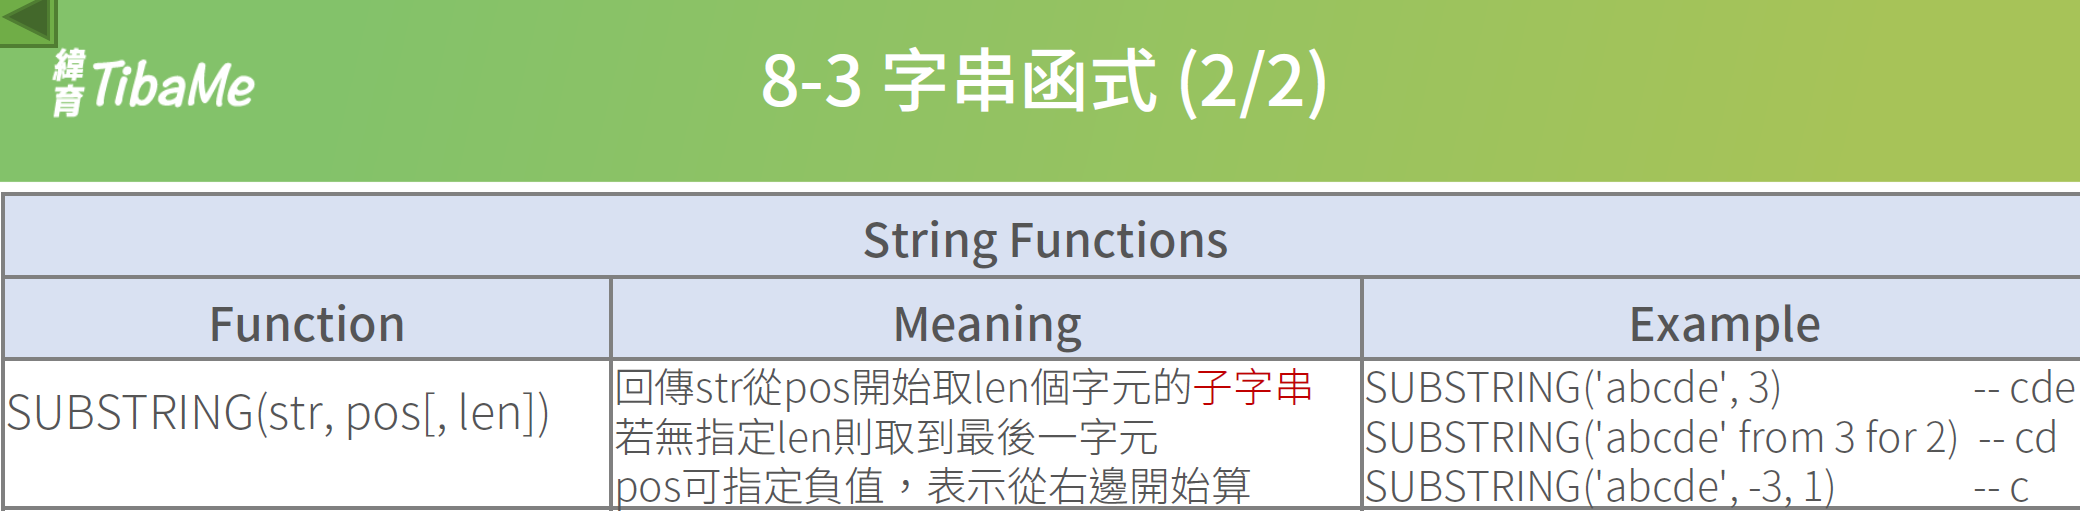

注意下圖

第一個值的位置不是從0開始, 而是1

從2開始 取3個也就是MIT

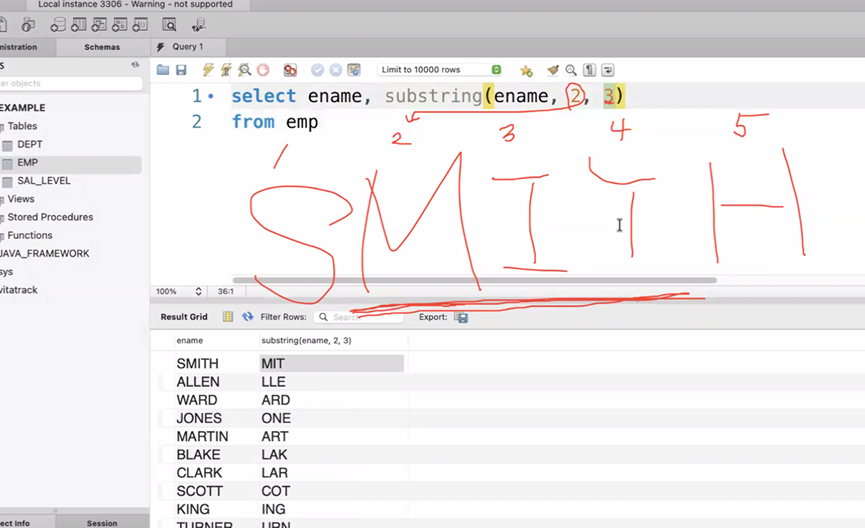

In [ ]:
group by 程式順序先分組, 再決定要找甚麼

p46
cast 都是型態轉換, 資料型態
CONVERT 不一定是資料型態的轉換

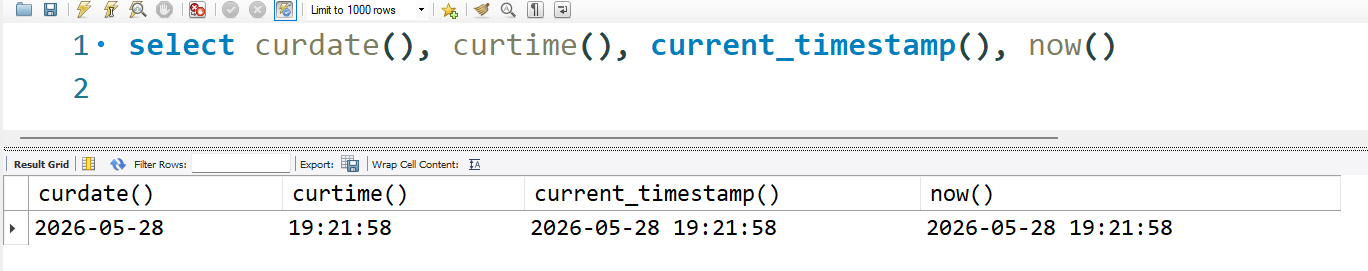

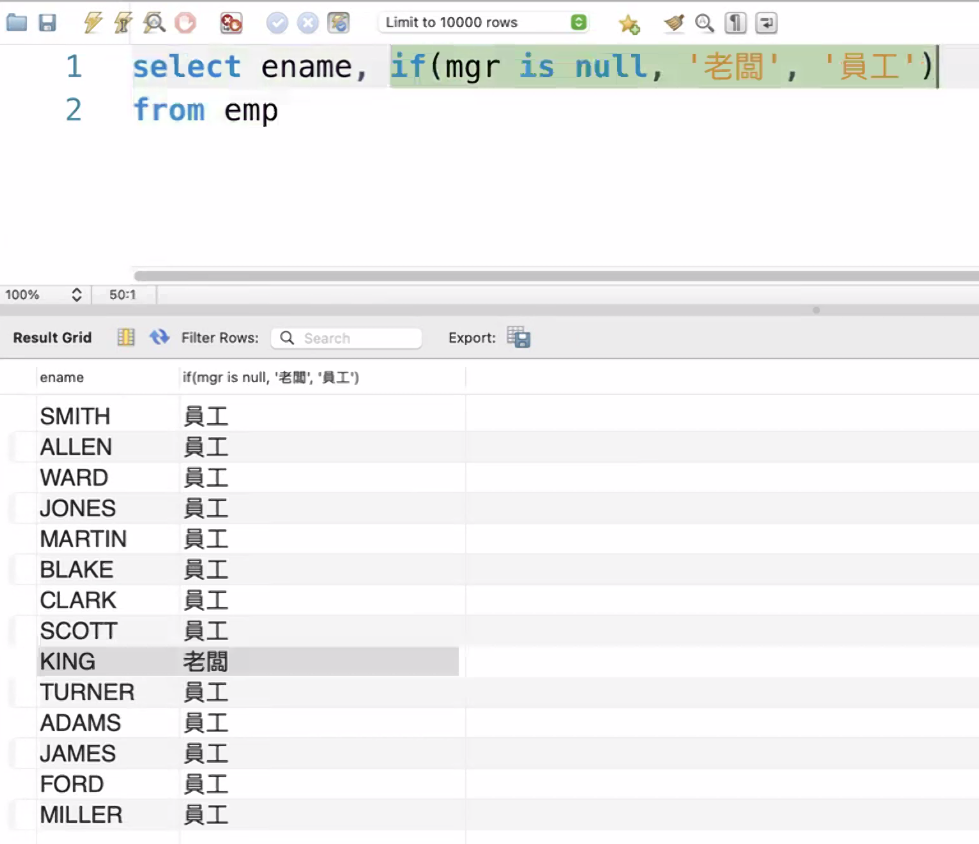

In [ ]:
# p49 群組函式
select deptno, count(*), max(sal), min(sal), sum(sal), avg(sal)
from emp
group by deptno

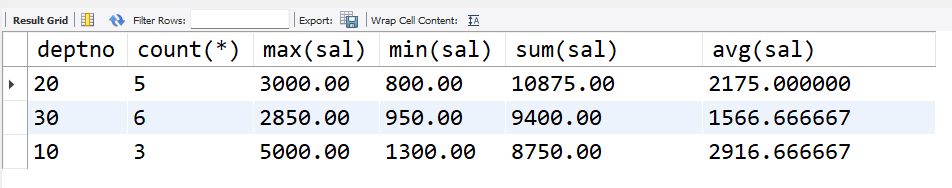

In [ ]:
# join 是左右連結table  ..p58

select *
from emp natural join dept;
# cross join 會把各種可行性都帶入, 亂拚, 無效資料

from emp cross join dept;
# natural join 會找出共通點帶到最左邊, 並且以這個條件做合併, 但實務上很少用, 表頭很難有共通點, 不同人有不同習慣, 就會變成cross join


# 因此大多數的寫法為
select *
from emp
	join dept
		on emp.deptno = dept.deptno


# SQL-89 老一輩的寫法
select *
from emp e, dept d
where e.deptno = d.deptno
# 輸出後長的跟JOIN ON (SQL-92)一樣

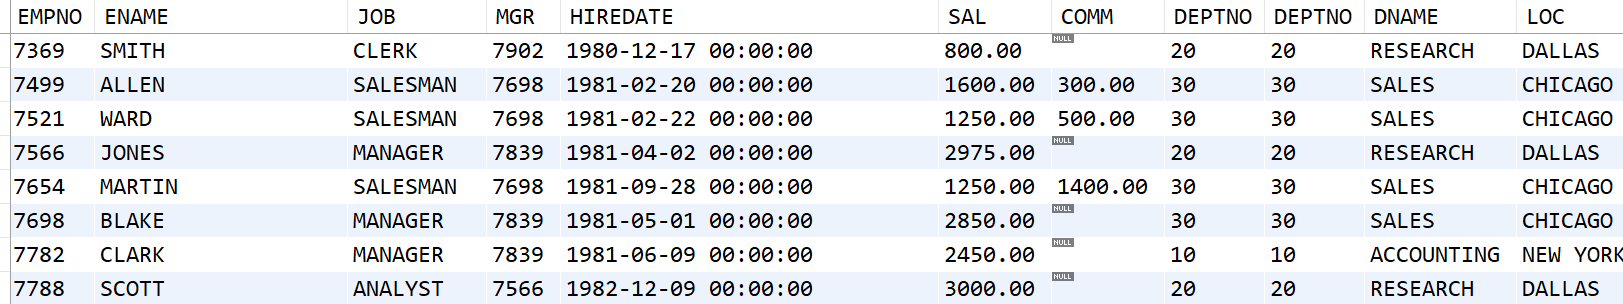

In [ ]:
#通常表格名稱很長, 要取別名, 不一定要用as語法
# 大多ON 後面都接 '='
select *
from emp e
	join dept d
		on e.deptno = d.deptno

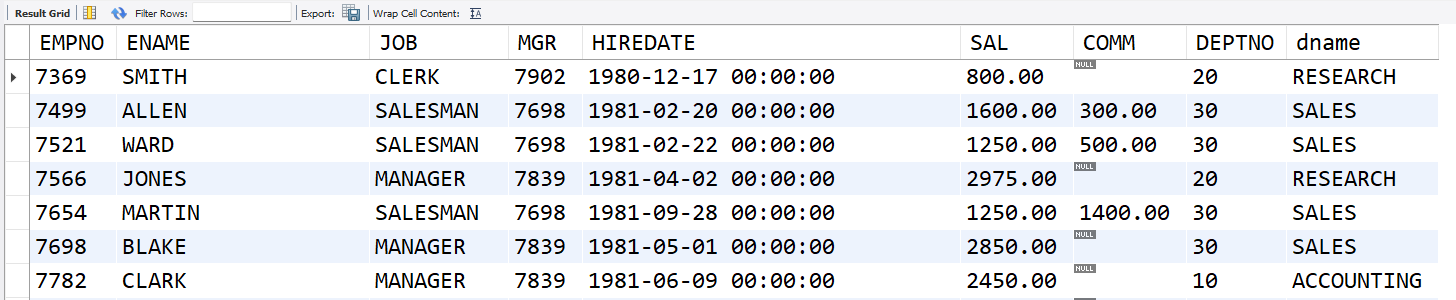

In [ ]:
# 新增薪資分級欄位
# 少數 on 後面不是 = 的案例
select *
from emp e
	join sal_level sl
		on e.sal between sl.sal_min and sl.sal_max

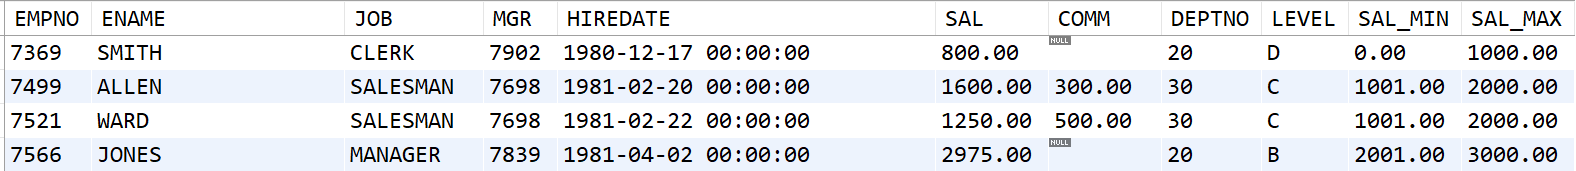

In [ ]:
# 只取部分
select e.deptno, e.ename, d.dname
from emp e
	join dept d
		on e.deptno = d.deptno

# 注意要加別名, 避免忘記資料哪裡來

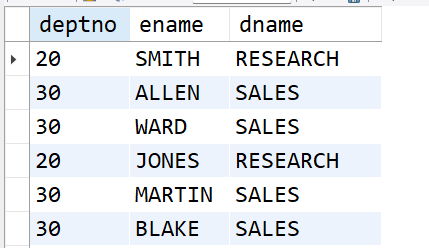

inner join
*  與join相同, A與B的交集

outer join
*  A left join B
*  B依A為主
*  join 出來的結果, 不會少於A的資料
*  工程師都是以left join, 如果要用B為主就是
*  B left join A
*  A left join B 等效  B right join A





In [ ]:
select *
from dept d
	join emp e
		on d.DEPTNO = e.DEPTNO

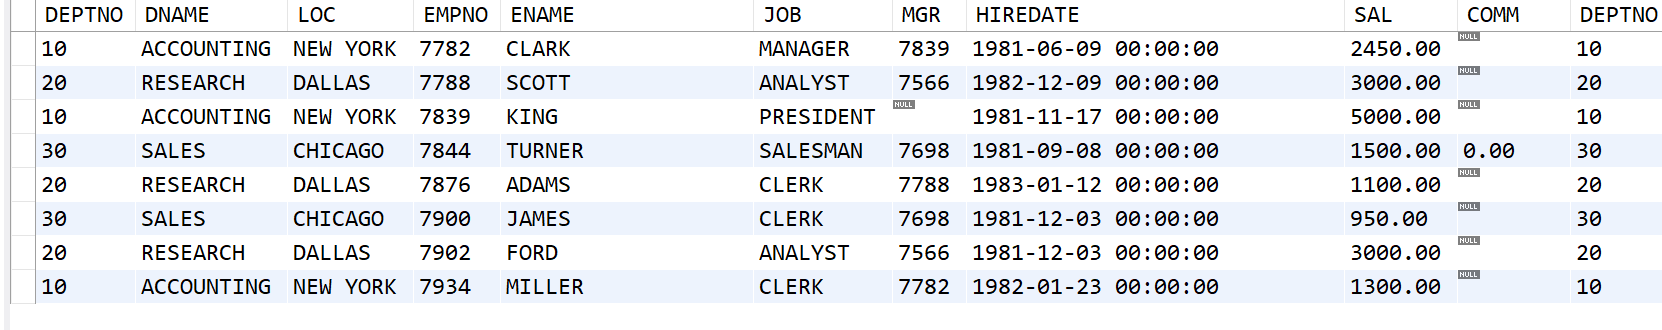

In [ ]:
select *
from dept d
	left join emp e
		on d.DEPTNO = e.DEPTNO

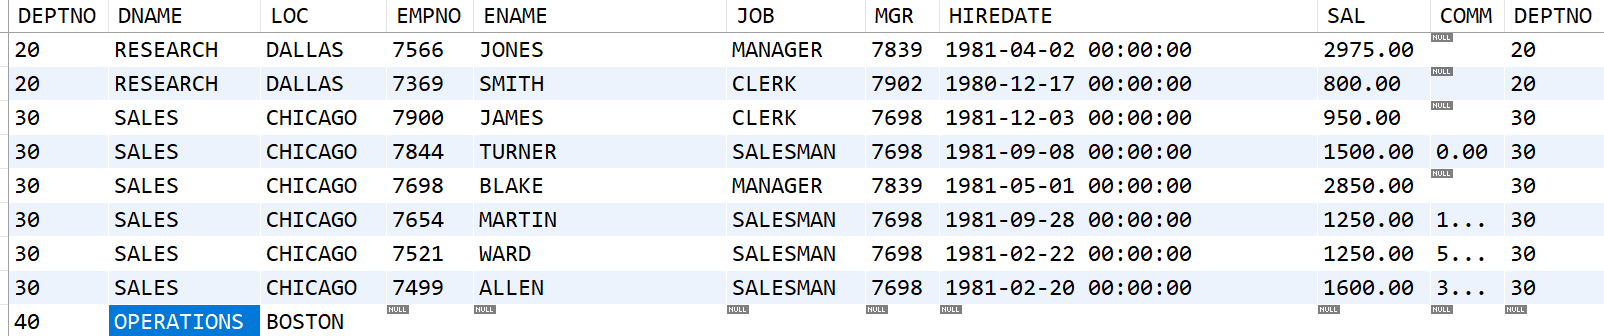

In [ ]:
# 找出沒有員工的部門, left join很常用

select *
from dept d
	left join emp e
		on d.DEPTNO = e.DEPTNO
where e.EMPNO is null

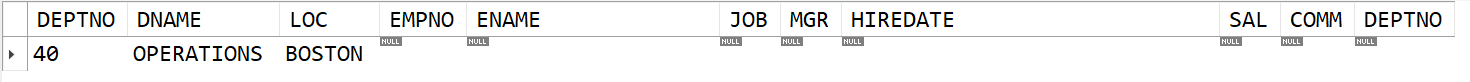

In [ ]:
# 同一table 就自己分成2個e1/ e2 或 a/ b
select *
from EMP e1
	join emp e2
		on e1.mgr = e2.empno

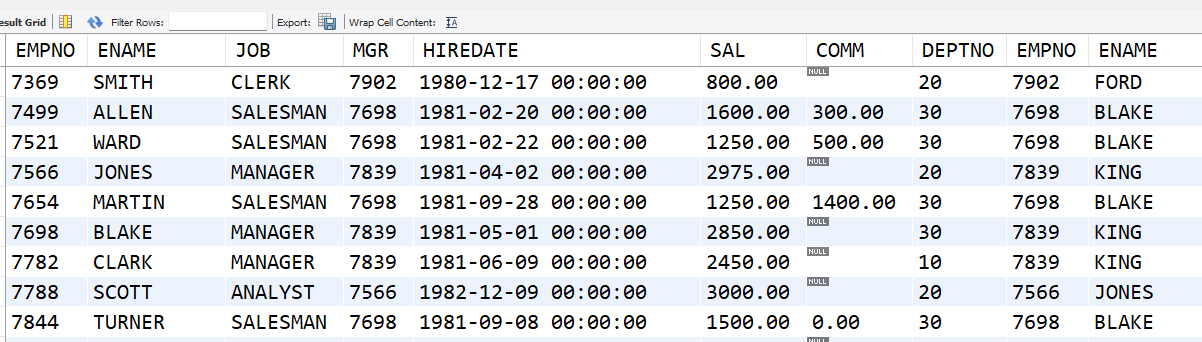

**p69**


select 子句只有6種, limit 有支援 my sql 算是方言的一種

相關子查詢能不用就不要用

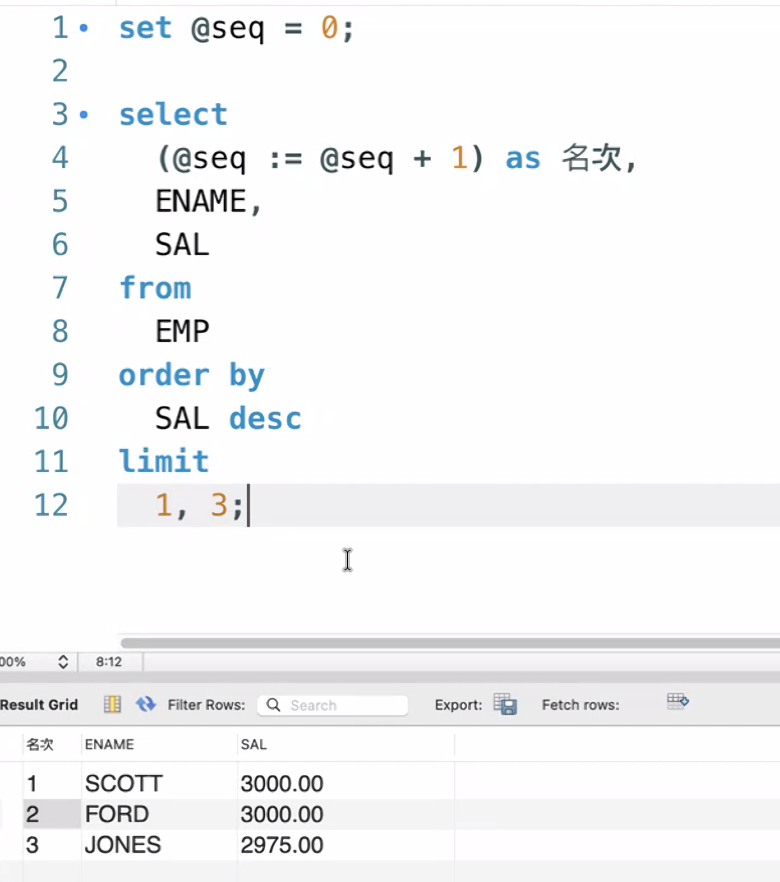

查詢的過程就好像跑回圈, 範例如下

In [ ]:
# select敘述-⼦查詢-相關⼦查詢
# 列出各部⾨薪資最⾼的員⼯
select
	DEPTNO,
	ENAME,
	SAL
from
	EMP e
where
	SAL = (
	select MAX(SAL)
	from EMP
	where DEPTNO = e.DEPTNO)
order by
	DEPTNO

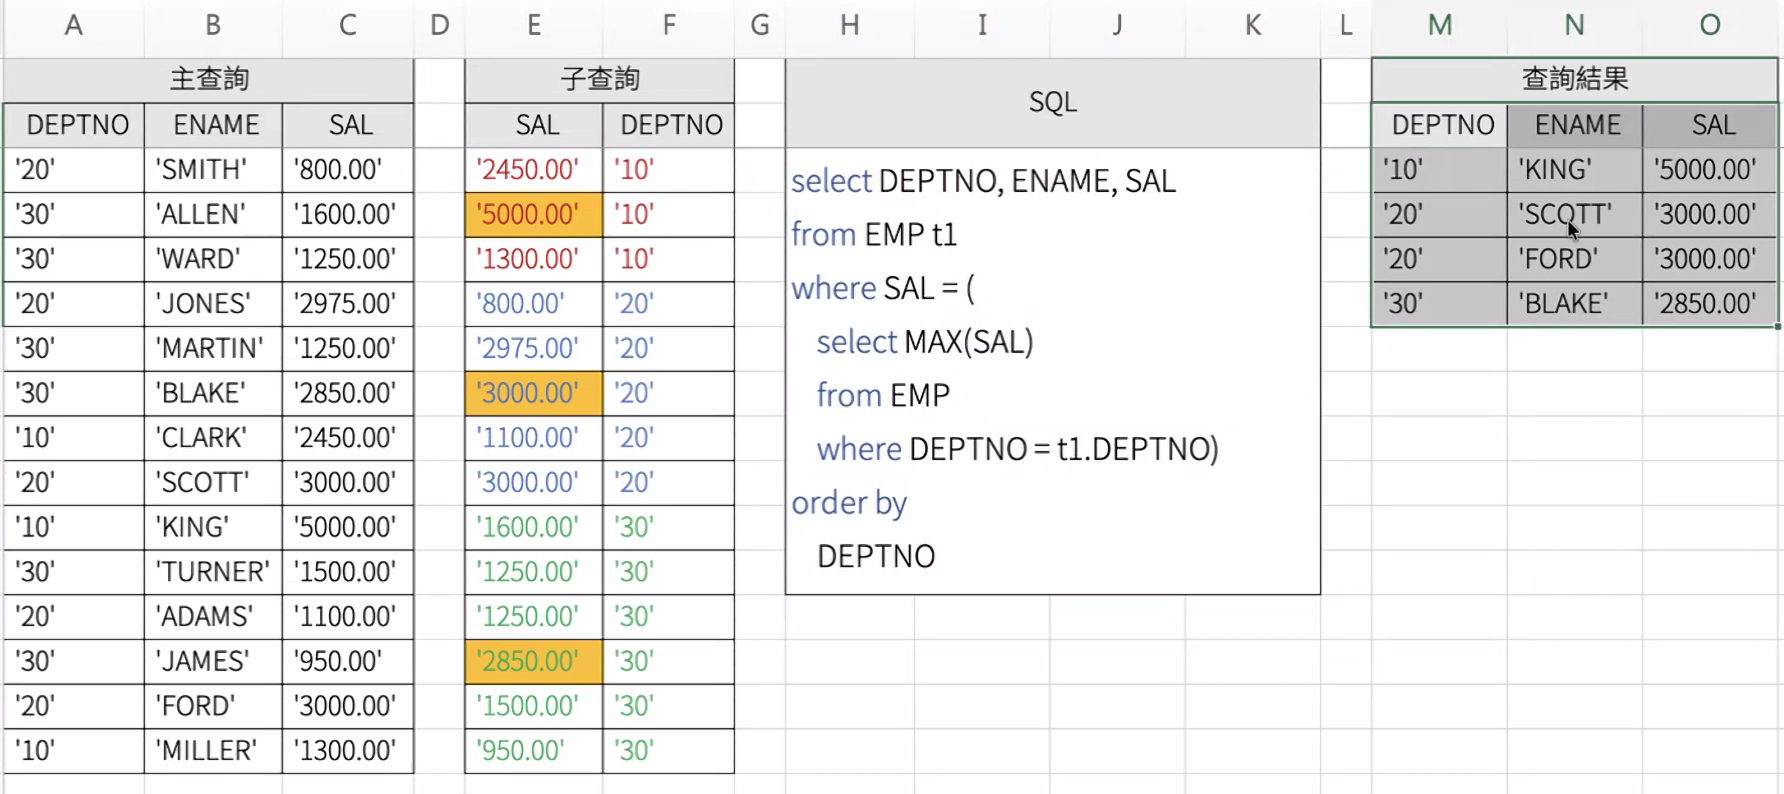

In [ ]:
# 子查詢教學
# 先分開想再合在一起

# step1: 算出平均薪資
select avg(sal) from emp;

# step2: 找出低於平均薪資的員工
select *
from emp
where sal < 2073.214286;


# 子查詢寫法
select *
from emp
where sal < (select avg(sal) from emp);

In [ ]:
# 子查詢如果使用在from子句, 必須+別名
# 子查詢可以跟子查詢join
# 子查詢必須()

select *
from (select avg(sal) from emp) t

In [ ]:
# 練習1 單欄多筆
# 列出在紐約上班的員工

# step1: 找出在new york的部門
select *
from dept
where loc = 'NEW YORK';

#找到要留下來可對照的資料
select deptno
from dept
where loc = 'NEW YORK';

# step2: 找出在這些部門上班的員工
select *
from emp
where deptno = 10;

# 組合
select *
from emp
where deptno = (
	select deptno
	from dept
	where loc = 'NEW YORK');

# 注意區別子查詢印出是單筆或多筆, 運算子的符號和英文要切換

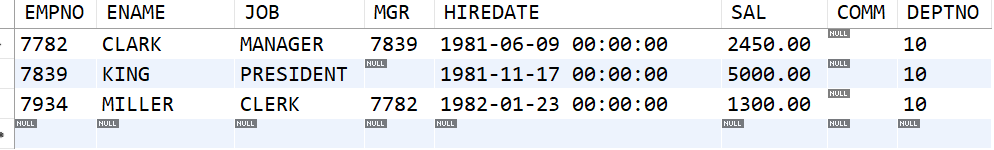

In [ ]:
# 練習2 多欄單筆
# 如果有and 怎麼串接成子查詢

# 列出跟員工編號7499的員工、同職稱、同主管的員工

#step1: 找出7499的職稱、主管
select job, mgr
from emp
where empno = 7499;

#step2: 找出相同的員工
select *
from emp
where job = 'salesman'
	and mgr = 7698;

# 結合
select *
from emp
where (job, mgr) = (
	select job, mgr
	from emp
	where empno = 7499);
    # ()=() 區塊 = 區塊

SyntaxError: invalid syntax (2369267518.py, line 6)

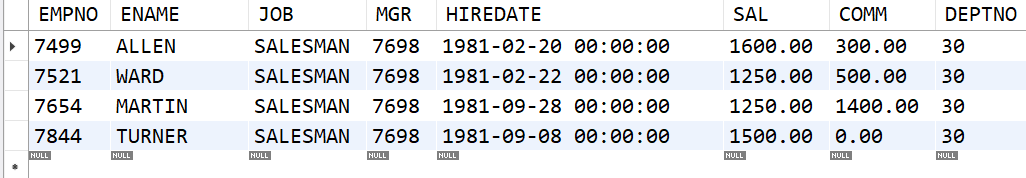

In [ ]:
# 練習 多欄多筆
# 列出 職稱跟薪水 有重複的員工

#step1: 找出有重複的職稱和薪水
select job, sal, count(*)
from emp
group by job, sal
having count(*)>1

#step2: 找出這些員工
select *
from emp
where job = 'SALESMAN' and sal = 1250
	or
    job = 'ANALYST' and sal = 3000;

# 組合
select *
from emp
where (job, sal) in (
	select job, sal
	from emp
	group by job, sal
	having count(*)>1);

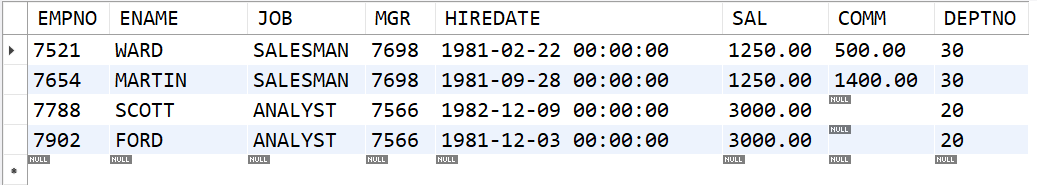


In [ ]:
# 請列出主管的主管是KING 的員工-3層

# step1
select empno
from emp
where ename = 'king'

# step2
select empno
from emp
where mgr = 7839

# step3
select *
from emp
where mgr in (7566, 7698, 7782)

# 結合-3層
select *
from emp
	where mgr in (
    select empno
	from emp
		where mgr = (
        select empno
		from emp
		where ename = 'king'));

pm


pmp 考試, 很重要


敏捷式 : 比如設計10%交給下面的去執行

瀑布式 : 全部做好設計, 交給下面, 費時沒效率